In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import pandas as pd
import os 

In [2]:
# File path to meteorological tower observations
filename = "/home/lacrio/cryoextremes-practicals/data/pross/met_data_1h.csv"

# Load CSV data
tower_df_b = pd.read_csv(filename)

# Parse datetime and adjust offset (+3 hours)
tower_df_b["datetime"] = pd.to_datetime(tower_df_b["datetime"]) + pd.Timedelta(hours=3)
tower_df_b = tower_df_b.set_index("datetime")
tower_df_b = tower_df_b.loc['2024-12-06':'2024-12-12']
tower_df_b

,SUp,SDn,LUpCo,LDnCo,tair,rh,press,ws,wd,SHF
datetime,,,,,,,,,,
2024-12-06 00:00:00,22.027583,-6.099033,221.720000,-304.818333,-1.373050,64.374667,1012.819867,0.0,0.671450,-6.790317
2024-12-06 01:00:00,1.502833,-2.493850,217.453333,-301.495000,-1.391417,64.466667,1013.244267,0.0,0.601633,-8.338000
2024-12-06 02:00:00,-3.403450,-1.519867,212.940000,-300.505000,-1.357817,61.972167,1013.110750,0.0,0.577800,-8.456500
2024-12-06 03:00:00,-3.904550,-1.224900,214.573333,-300.468333,-1.296033,62.300667,1013.238967,0.0,0.573400,-8.127267
2024-12-06 04:00:00,-3.590267,-1.192567,215.496667,-300.398333,-1.429483,69.043833,1013.181883,0.0,0.576200,-7.540617
...,...,...,...,...,...,...,...,...,...,...
2024-12-12 19:00:00,467.903333,-79.011000,314.971667,-358.168333,3.698367,88.823333,989.056863,0.0,1.259200,11.324500
2024-12-12 20:00:00,282.215500,-46.891833,318.570000,-356.731667,3.852717,88.481667,989.488888,0.0,1.325600,14.123000
2024-12-12 21:00:00,88.573333,-14.415017,326.713333,-346.688333,4.117917,87.811667,989.720933,0.0,1.268000,9.782200


In [3]:
filename = 'data/pross/data_tower.csv'
tower_df = pd.read_csv(filename, sep='\t')
# --- Preparación de datos e índices temporales ---
tower_df["datetime"] = pd.to_datetime(tower_df["datetime"])
tower_df = tower_df.set_index("datetime")
tower_df.columns

Index(['SUp', 'SDn', 'LUpCo', 'LDnCo', 'SHF', 'H', 'LE', 'Rn', 'SEB_Consumed',
       'SEB_Residual', 'air_temperature', 'air_pressure', 'RH', 'wind_speed',
       'wind_dir'],
      dtype='object')

In [4]:
filename = 'data/pross/data_buoy_full_time.csv'
bouy_df = pd.read_csv(filename, sep='\t')
bouy_df["datetime"] = pd.to_datetime(bouy_df["datetime"])
bouy_df = bouy_df.set_index("datetime")
bouy_df.columns

Index(['ws', 'tair', 'rh', 'press', 'SUp', 'sst', 'H', 'LE'], dtype='object')

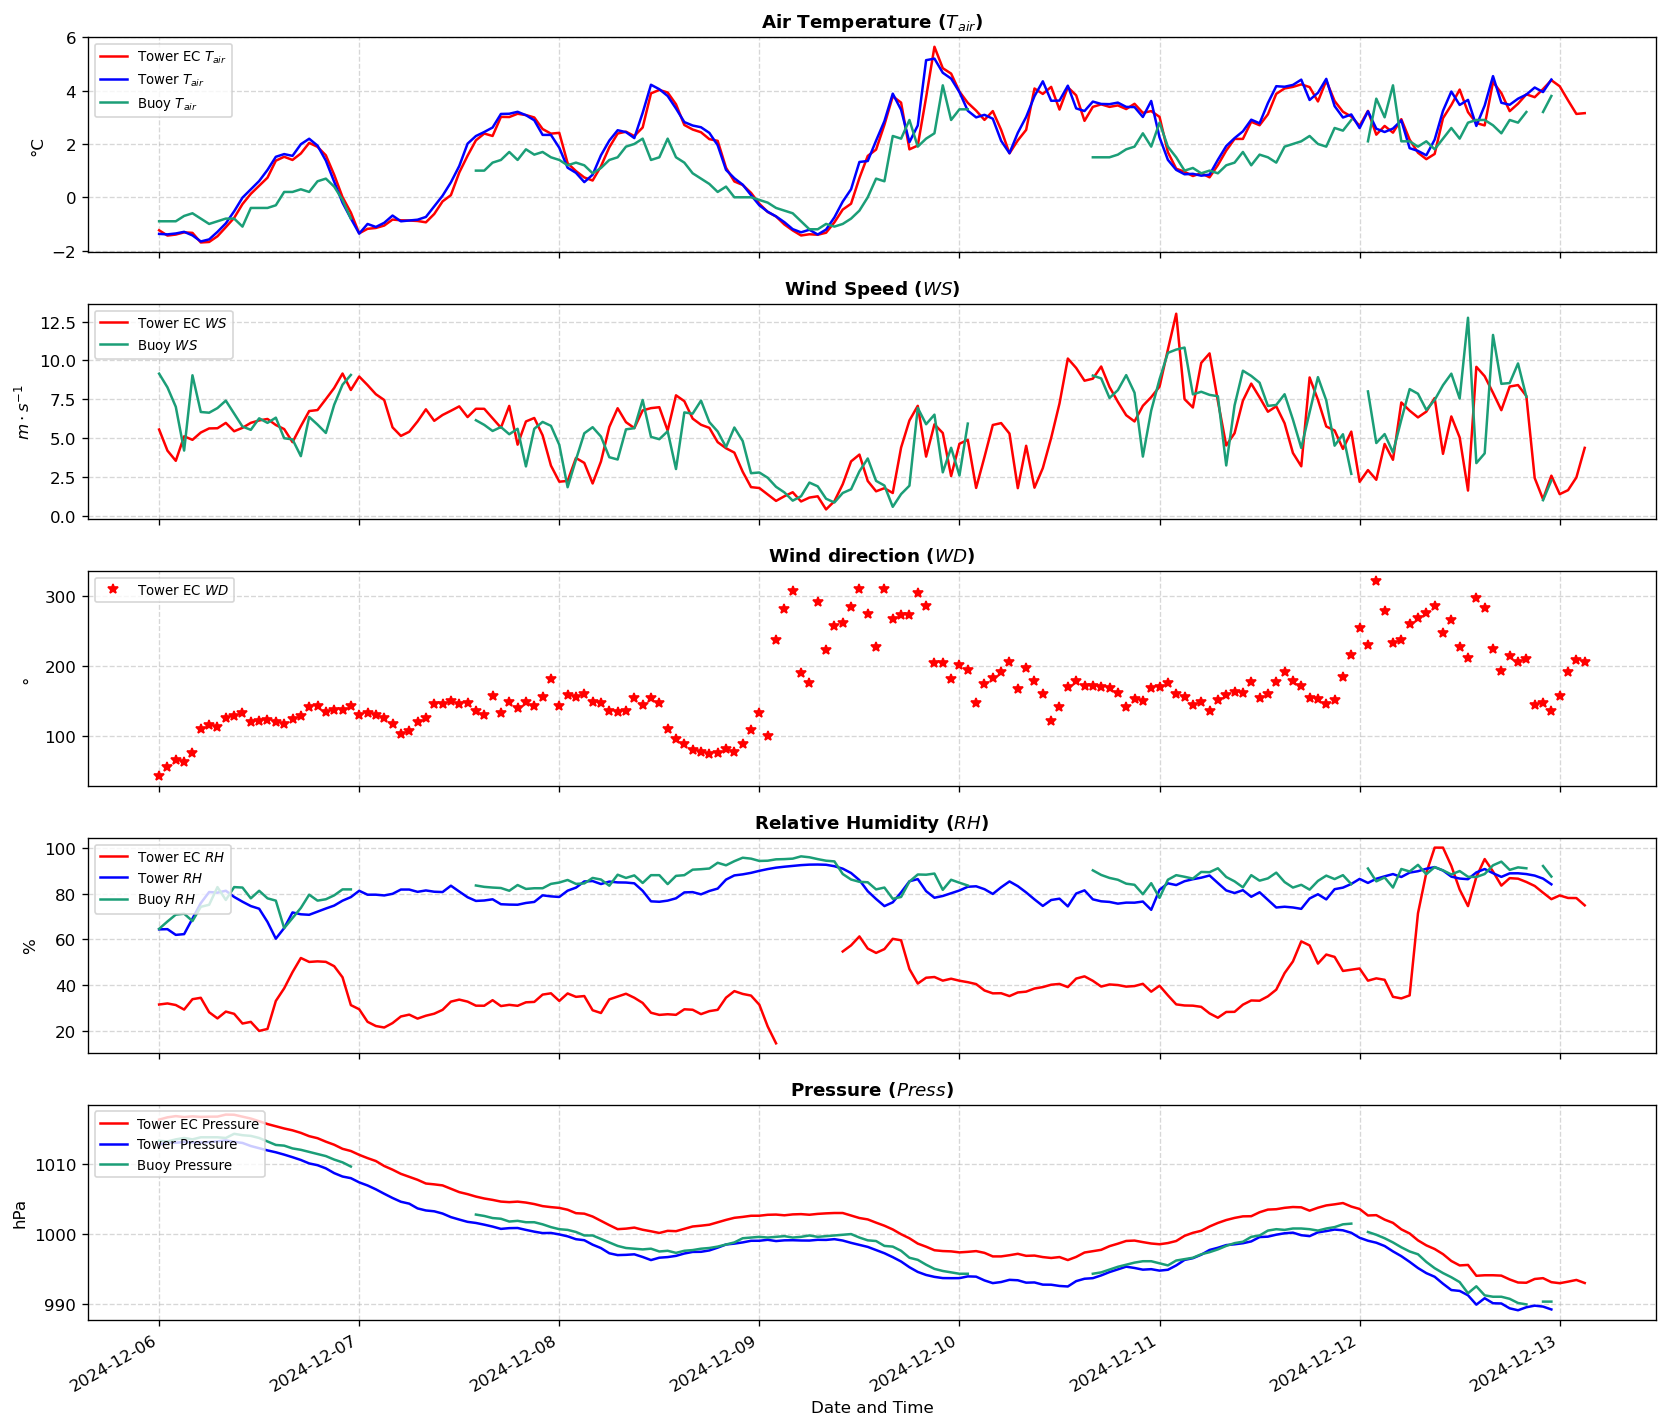

In [5]:
import matplotlib.pyplot as plt

# Definir colores consistentes
color_tower   = "red"  # Naranja
color_tower_l = "blue"  # red
color_buoy    = "#1b9e77"   # Verde

# ==============================================================================
# FIGURA 1: Variables Meteorológicas (tair, ws, rh, press)
# ==============================================================================
fig1, (ax1, ax2, ax3, ax4, ax5) = plt.subplots(
    5, 1, figsize=(14, 12), sharex=True, dpi=120
)

# 1. Air Temperature (tair)
ax1.plot(
    tower_df.index,
    tower_df["air_temperature"]-273.15,
    label="Tower EC $T_{air}$",
    color=color_tower,
    linewidth=1.5,
)

ax1.plot(
    tower_df_b.index,
    tower_df_b["tair"],
    label="Tower $T_{air}$",
    color=color_tower_l,
    linewidth=1.5,
)

ax1.plot(
    bouy_df.index,
    bouy_df["tair"],
    label="Buoy $T_{air}$",
    color=color_buoy,
    linewidth=1.5,
)
ax1.set_title("Air Temperature ($T_{air}$)", fontsize=11, fontweight="bold")
ax1.set_ylabel("°C", fontsize=10)
ax1.grid(True, linestyle="--", alpha=0.5)
ax1.legend(loc="upper left", frameon=True, facecolor="white", fontsize=8)

# 2. Wind Speed (ws)
ax2.plot(
    tower_df.index,
    tower_df["wind_speed"],
    label="Tower EC $WS$",
    color=color_tower,
    linewidth=1.5,
)

ax2.plot(
    bouy_df.index,
    bouy_df["ws"],
    label="Buoy $WS$",
    color=color_buoy,
    linewidth=1.5,
)
ax2.set_title("Wind Speed ($WS$)", fontsize=11, fontweight="bold")
ax2.set_ylabel("$m \\cdot s^{-1}$", fontsize=10)
ax2.grid(True, linestyle="--", alpha=0.5)
ax2.legend(loc="upper left", frameon=True, facecolor="white", fontsize=8)


# 3. Wind direction (wd)
ax3.plot(
    tower_df.index,
    tower_df["wind_dir"], '*',
    label="Tower EC $WD$",
    color=color_tower,
    linewidth=1.5,
)

ax3.set_title("Wind direction ($WD$)", fontsize=11, fontweight="bold")
ax3.set_ylabel("°", fontsize=10)
ax3.grid(True, linestyle="--", alpha=0.5)
ax3.legend(loc="upper left", frameon=True, facecolor="white", fontsize=8)


# 4. Relative Humidity (rh)
ax4.plot(
    tower_df.index,
    tower_df["RH"],
    label="Tower EC $RH$",
    color=color_tower,
    linewidth=1.5,
)

ax4.plot(
    tower_df_b.index,
    tower_df_b["rh"],
    label="Tower $RH$",
    color=color_tower_l,
    linewidth=1.5,
)
ax4.plot(
    bouy_df.index,
    bouy_df["rh"],
    label="Buoy $RH$",
    color=color_buoy,
    linewidth=1.5,
)
ax4.set_title("Relative Humidity ($RH$)", fontsize=11, fontweight="bold")
ax4.set_ylabel("%", fontsize=10)
ax4.grid(True, linestyle="--", alpha=0.5)
ax4.legend(loc="upper left", frameon=True, facecolor="white", fontsize=8)

# 5. Pressure (press)
ax5.plot(
    tower_df.index,
    tower_df["air_pressure"]/100,
    label="Tower EC Pressure",
    color=color_tower,
    linewidth=1.5,
)

ax5.plot(
    tower_df_b.index,
    tower_df_b["press"],
    label="Tower Pressure",
    color=color_tower_l,
    linewidth=1.5,
)
ax5.plot(
    bouy_df.index,
    bouy_df["press"],
    label="Buoy Pressure",
    color=color_buoy,
    linewidth=1.5,
)
ax5.set_title("Pressure ($Press$)", fontsize=11, fontweight="bold")
ax5.set_xlabel("Date and Time", fontsize=10)
ax5.set_ylabel("hPa", fontsize=10)
ax5.grid(True, linestyle="--", alpha=0.5)
ax5.legend(loc="upper left", frameon=True, facecolor="white", fontsize=8)

fig1.autofmt_xdate()
fig1.tight_layout()

# Save figure
output_dir = "fig"
save_path = os.path.join(output_dir, f"fig_tower_bouy.png")
plt.savefig(save_path, dpi=200, bbox_inches="tight")

plt.show()

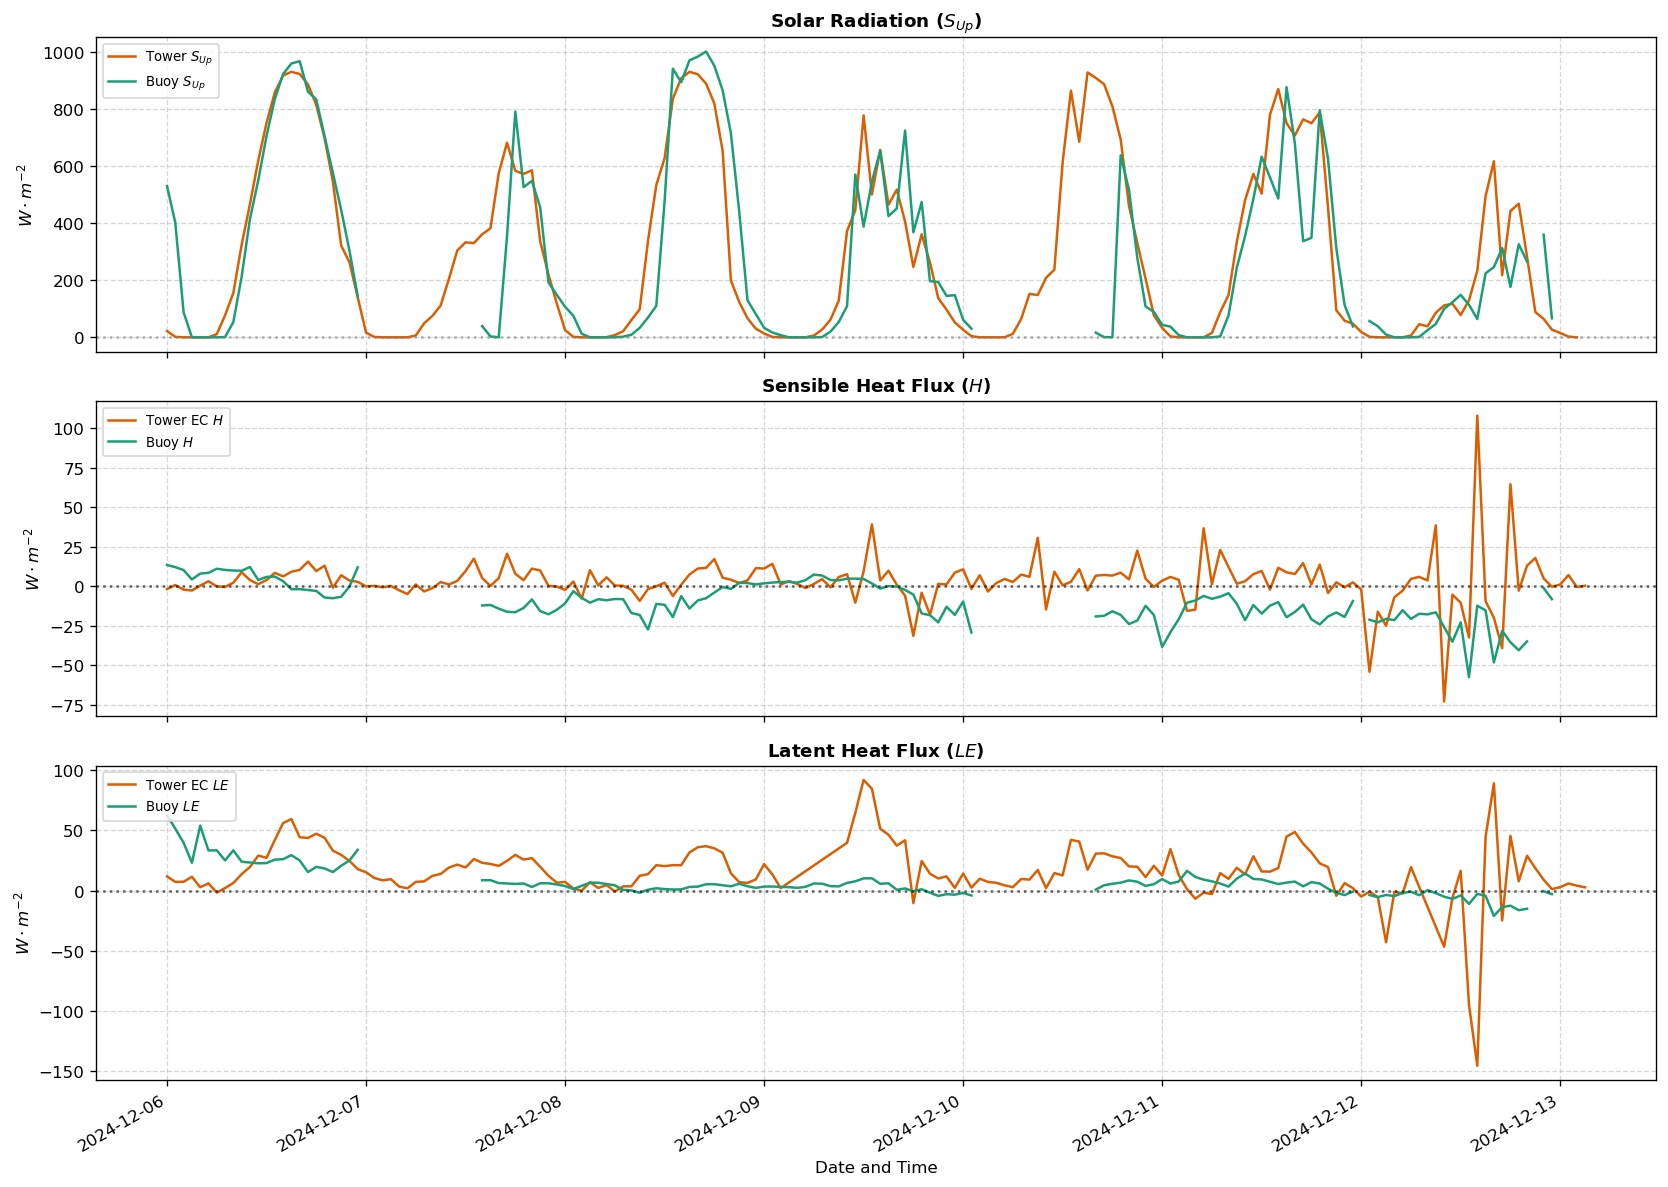

In [6]:
import matplotlib.pyplot as plt

# Definir los mismos colores consistentes
color_tower = "#d95f02"  # Naranja
color_buoy = "#1b9e77"  # Verde

# ==============================================================================
# FIGURA 2: Radiación Solar y Flujos Turbulentos (SUp, H, LE)
# ==============================================================================
fig2, (ax_sup, ax_h, ax_le) = plt.subplots(
    3, 1, figsize=(14, 10), sharex=True, dpi=120
)

# 1. Solar Radiation (SUp)
ax_sup.plot(
    tower_df.index,
    tower_df["SUp"],
    label="Tower $S_{Up}$",
    color=color_tower,
    linewidth=1.5,
)
ax_sup.plot(
    bouy_df.index,
    bouy_df["SUp"],
    label="Buoy $S_{Up}$",
    color=color_buoy,
    linewidth=1.5,
)
ax_sup.set_title("Solar Radiation ($S_{Up}$)", fontsize=11, fontweight="bold")
ax_sup.set_ylabel("$W \\cdot m^{-2}$", fontsize=10)
ax_sup.axhline(0, color="gray", linestyle=":", alpha=0.6)
ax_sup.grid(True, linestyle="--", alpha=0.5)
ax_sup.legend(loc="upper left", frameon=True, facecolor="white", fontsize=8)

# 2. Sensible Heat Flux (H)
ax_h.plot(
    tower_df.index,
    tower_df["H"],
    label="Tower EC $H$",
    color=color_tower,
    linewidth=1.5,
)
ax_h.plot(
    bouy_df.index,
    bouy_df["H"],
    label="Buoy $H$",
    color=color_buoy,
    linewidth=1.5,
)
ax_h.set_title("Sensible Heat Flux ($H$)", fontsize=11, fontweight="bold")
ax_h.set_ylabel("$W \\cdot m^{-2}$", fontsize=10)
ax_h.axhline(0, color="black", linestyle=":", alpha=0.6)
ax_h.grid(True, linestyle="--", alpha=0.5)
ax_h.legend(loc="upper left", frameon=True, facecolor="white", fontsize=8)

# 3. Latent Heat Flux (LE)
ax_le.plot(
    tower_df.index,
    tower_df["LE"],
    label="Tower EC $LE$",
    color=color_tower,
    linewidth=1.5,
)
ax_le.plot(
    bouy_df.index,
    bouy_df["LE"],
    label="Buoy $LE$",
    color=color_buoy,
    linewidth=1.5,
)
ax_le.set_title("Latent Heat Flux ($LE$)", fontsize=11, fontweight="bold")
ax_le.set_xlabel("Date and Time", fontsize=10)
ax_le.set_ylabel("$W \\cdot m^{-2}$", fontsize=10)
ax_le.axhline(0, color="black", linestyle=":", alpha=0.6)
ax_le.grid(True, linestyle="--", alpha=0.5)
ax_le.legend(loc="upper left", frameon=True, facecolor="white", fontsize=8)

fig2.autofmt_xdate()
fig2.tight_layout()
plt.show()